# Research Question 3 – Significant Butter Price Deviations (Using Your Uploaded API Data)

**Question:**  
Which months between 2020 and 2024 exhibit statistically significant deviations in retail butter prices that cannot be explained by underlying dairy commodity trends or normal seasonal price patterns?

This notebook uses the **local files you uploaded**, which are exports of your API data:
- `eurostat_butter_cpi.json`
- `eurostat_ppi_dairy.json`
- `eurostat_cpi_dairy.json`

## Why these three files fit the research question
- **Butter CPI / HICP** represents the retail butter price series.
- **Dairy PPI** represents producer-side dairy commodity and cost pressure.
- **Dairy CPI / HICP** represents broader dairy-related consumer inflation pressure.

So I do **not** need live APIs here, because the relevant API data is already available as local files.

## Analysis idea
We estimate an expected butter price from:
1. dairy producer-price trends,
2. broader dairy consumer inflation,
3. normal seasonal month patterns,
4. a simple time trend.

Then we calculate residuals:
- **positive residual** = butter is more expensive than expected,
- **negative residual** = butter is cheaper than expected.

Months with unusually large standardised residuals are flagged as statistically significant deviations.


In [43]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Configuration

Here we define file paths, the analysis period, and the significance threshold.


In [44]:
BASE_DIR = Path(".")

BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"
DAIRY_CPI_FILE = BASE_DIR / "eurostat_cpi_dairy.json"

ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END = pd.Timestamp("2024-12-31")

# Rule of thumb: absolute z-score >= 2 means the month is unusually far from the model expectation.
Z_SCORE_THRESHOLD = 2.0


## 2. Helper function: Read Eurostat JSON

All three uploaded files follow a Eurostat-style nested JSON structure.  
This function converts them into clean monthly DataFrames.


In [45]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """
    Read a Eurostat-style JSON file and convert it into a monthly DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to the local JSON file.
    value_name : str
        Name of the numeric value column.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - datum
        - <value_name>
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for label_key, position in time_index.items():
        position_str = str(position)

        # Only keep months that really contain a value.
        if position_str in values:
            rows.append(
                {
                    "datum_raw": time_labels[label_key],
                    value_name: values[position_str],
                }
            )

    df = pd.DataFrame(rows)

    # Your uploaded Eurostat files use labels such as "2020-01".
    df["datum"] = pd.to_datetime(df["datum_raw"], errors="coerce")
    df.drop(columns=["datum_raw"], inplace=True)

    # Invalid strings are converted to NaN so we can clean them systematically.
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df


## 3. Helper function: Data cleaning

This is the main cleaning step.  
We remove invalid dates, missing values, duplicates, and keep only the requested time window.


In [46]:
def clean_time_series(
    df: pd.DataFrame,
    value_column: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Clean a monthly time series.

    Cleaning steps
    --------------
    - remove missing dates,
    - remove missing values,
    - remove duplicate months,
    - sort chronologically,
    - restrict to the analysis period.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with one row per month.
    """
    cleaned_df = df.copy()

    cleaned_df = cleaned_df.dropna(subset=["datum", value_column])
    cleaned_df = cleaned_df.drop_duplicates(subset=["datum"], keep="last")
    cleaned_df = cleaned_df.sort_values("datum").reset_index(drop=True)

    cleaned_df = cleaned_df[
        (cleaned_df["datum"] >= start_date) & (cleaned_df["datum"] <= end_date)
    ].copy()

    return cleaned_df


def print_data_quality_report(df: pd.DataFrame, title: str) -> None:
    """
    Print a compact data-quality report.
    """
    print("=" * 72)
    print(title)
    print("=" * 72)
    print(f"Rows: {len(df)}")
    print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate months:", int(df["datum"].duplicated().sum()))
    print("=" * 72)


## 4. Load and clean the three uploaded API datasets


In [47]:
butter_raw_df = eurostat_json_to_df(BUTTER_FILE, "butter_cpi")
ppi_raw_df = eurostat_json_to_df(PPI_FILE, "dairy_ppi")
dairy_cpi_raw_df = eurostat_json_to_df(DAIRY_CPI_FILE, "dairy_cpi")

butter_clean_df = clean_time_series(
    butter_raw_df,
    value_column="butter_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

ppi_clean_df = clean_time_series(
    ppi_raw_df,
    value_column="dairy_ppi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

dairy_cpi_clean_df = clean_time_series(
    dairy_cpi_raw_df,
    value_column="dairy_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print_data_quality_report(butter_clean_df, "BUTTER DATA QUALITY REPORT")
print_data_quality_report(ppi_clean_df, "DAIRY PPI DATA QUALITY REPORT")
print_data_quality_report(dairy_cpi_clean_df, "DAIRY CPI DATA QUALITY REPORT")


BUTTER DATA QUALITY REPORT
Rows: 60
Date range: 2020-01-01 to 2024-12-01

Missing values per column:
butter_cpi    0
datum         0
dtype: int64

Duplicate months: 0
DAIRY PPI DATA QUALITY REPORT
Rows: 48
Date range: 2020-01-01 to 2023-12-01

Missing values per column:
dairy_ppi    0
datum        0
dtype: int64

Duplicate months: 0
DAIRY CPI DATA QUALITY REPORT
Rows: 60
Date range: 2020-01-01 to 2024-12-01

Missing values per column:
dairy_cpi    0
datum        0
dtype: int64

Duplicate months: 0


## 5. Merge the three series and create analysis features

This is the central transformation step.  
We combine:
- butter retail prices,
- dairy producer prices,
- broader dairy consumer prices.


In [48]:
def merge_and_engineer_features(
    butter_df: pd.DataFrame,
    ppi_df: pd.DataFrame,
    dairy_cpi_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge the three series and create modelling features.
    """
    merged_df = pd.merge(butter_df, ppi_df, on="datum", how="inner")
    merged_df = pd.merge(merged_df, dairy_cpi_df, on="datum", how="inner")
    merged_df = merged_df.sort_values("datum").reset_index(drop=True)

    # Month-over-month changes.
    merged_df["butter_mom_pct"] = merged_df["butter_cpi"].pct_change() * 100
    merged_df["dairy_ppi_mom_pct"] = merged_df["dairy_ppi"].pct_change() * 100
    merged_df["dairy_cpi_mom_pct"] = merged_df["dairy_cpi"].pct_change() * 100

    # Year-over-year changes.
    merged_df["butter_yoy_pct"] = merged_df["butter_cpi"].pct_change(12) * 100
    merged_df["dairy_ppi_yoy_pct"] = merged_df["dairy_ppi"].pct_change(12) * 100
    merged_df["dairy_cpi_yoy_pct"] = merged_df["dairy_cpi"].pct_change(12) * 100

    # Lagged producer-side effects.
    merged_df["dairy_ppi_mom_lag1"] = merged_df["dairy_ppi_mom_pct"].shift(1)
    merged_df["dairy_ppi_mom_lag2"] = merged_df["dairy_ppi_mom_pct"].shift(2)
    merged_df["dairy_ppi_mom_lag3"] = merged_df["dairy_ppi_mom_pct"].shift(3)

    # Lagged consumer-side dairy inflation.
    merged_df["dairy_cpi_mom_lag1"] = merged_df["dairy_cpi_mom_pct"].shift(1)
    merged_df["dairy_cpi_yoy_lag1"] = merged_df["dairy_cpi_yoy_pct"].shift(1)

    # Calendar month for seasonality.
    merged_df["month"] = merged_df["datum"].dt.month
    month_dummies = pd.get_dummies(merged_df["month"], prefix="month", drop_first=True)

    # Simple time trend.
    merged_df["time_index"] = np.arange(len(merged_df))

    merged_df = pd.concat([merged_df, month_dummies], axis=1)

    return merged_df


In [49]:
analysis_df = merge_and_engineer_features(
    butter_clean_df,
    ppi_clean_df,
    dairy_cpi_clean_df,
)

print_data_quality_report(analysis_df, "MERGED ANALYSIS DATA QUALITY REPORT")

analysis_df.head()


MERGED ANALYSIS DATA QUALITY REPORT
Rows: 48
Date range: 2020-01-01 to 2023-12-01

Missing values per column:
butter_cpi             0
datum                  0
dairy_ppi              0
dairy_cpi              0
butter_mom_pct         1
dairy_ppi_mom_pct      1
dairy_cpi_mom_pct      1
butter_yoy_pct        12
dairy_ppi_yoy_pct     12
dairy_cpi_yoy_pct     12
dairy_ppi_mom_lag1     2
dairy_ppi_mom_lag2     3
dairy_ppi_mom_lag3     4
dairy_cpi_mom_lag1     2
dairy_cpi_yoy_lag1    13
month                  0
time_index             0
month_2                0
month_3                0
month_4                0
month_5                0
month_6                0
month_7                0
month_8                0
month_9                0
month_10               0
month_11               0
month_12               0
dtype: int64

Duplicate months: 0


,butter_cpi,datum,dairy_ppi,dairy_cpi,butter_mom_pct,dairy_ppi_mom_pct,dairy_cpi_mom_pct,butter_yoy_pct,dairy_ppi_yoy_pct,dairy_cpi_yoy_pct,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,144.9,2020-01-01,111.4,110.9,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,143.3,2020-02-01,111.9,110.9,-1.104210,0.448833,0.000000,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,142.7,2020-03-01,111.4,111.1,-0.418702,-0.446828,0.180343,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
3,142.5,2020-04-01,109.6,111.6,-0.140154,-1.615799,0.450045,NaN,NaN,NaN,...,False,True,False,False,False,False,False,False,False,False
4,142.3,2020-05-01,108.1,113.2,-0.140351,-1.368613,1.433692,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False


## 6. Estimate expected butter prices with a simple OLS model

We explain butter CPI using:
- dairy producer-price levels and changes,
- broader dairy CPI levels and changes,
- seasonal month dummies,
- time trend.

Then we use residuals to detect months that remain unusually high or low.


In [50]:
def fit_ols_via_numpy(df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, list[str]]:
    """
    Fit a simple OLS model using NumPy.

    Returns
    -------
    tuple
        model_df : DataFrame used in estimation
        beta     : estimated coefficients
        x_cols   : predictor columns
    """
    month_dummy_columns = [column for column in df.columns if column.startswith("month_")]

    x_cols = [
        "dairy_ppi",
        "dairy_cpi",
        "dairy_ppi_mom_pct",
        "dairy_ppi_mom_lag1",
        "dairy_ppi_mom_lag2",
        "dairy_ppi_mom_lag3",
        "dairy_ppi_yoy_pct",
        "dairy_cpi_mom_pct",
        "dairy_cpi_mom_lag1",
        "dairy_cpi_yoy_pct",
        "dairy_cpi_yoy_lag1",
        "time_index",
    ] + month_dummy_columns

    model_df = df[["datum", "butter_cpi"] + x_cols].dropna().copy()

    X = model_df[x_cols].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(model_df)), X])

    y = model_df["butter_cpi"].astype(float).to_numpy()

    beta = np.linalg.pinv(X.T @ X) @ X.T @ y

    return model_df, beta, x_cols


In [51]:
model_df, beta, x_cols = fit_ols_via_numpy(analysis_df)

print("Number of months used in the model:", len(model_df))
print("Number of predictors:", len(x_cols))


Number of months used in the model: 35
Number of predictors: 23


## 7. Compute fitted values, residuals, z-scores, and significance flags


In [52]:
def add_model_results(
    model_df: pd.DataFrame,
    beta: np.ndarray,
    x_cols: list[str],
    z_score_threshold: float,
) -> pd.DataFrame:
    """
    Add fitted values and identify statistically unusual months.
    """
    results_df = model_df.copy()

    X = results_df[x_cols].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(results_df)), X])

    results_df["predicted_butter_cpi"] = X @ beta
    results_df["residual"] = results_df["butter_cpi"] - results_df["predicted_butter_cpi"]

    residual_std = results_df["residual"].std(ddof=1)
    results_df["residual_zscore"] = results_df["residual"] / residual_std

    results_df["significant_deviation"] = (
        results_df["residual_zscore"].abs() >= z_score_threshold
    )

    results_df["deviation_direction"] = np.where(
        results_df["residual_zscore"] >= z_score_threshold,
        "higher_than_expected",
        np.where(
            results_df["residual_zscore"] <= -z_score_threshold,
            "lower_than_expected",
            "not_significant",
        ),
    )

    return results_df


In [53]:
results_df = add_model_results(
    model_df=model_df,
    beta=beta,
    x_cols=x_cols,
    z_score_threshold=Z_SCORE_THRESHOLD,
)

results_df.head()


,datum,butter_cpi,dairy_ppi,dairy_cpi,dairy_ppi_mom_pct,dairy_ppi_mom_lag1,dairy_ppi_mom_lag2,dairy_ppi_mom_lag3,dairy_ppi_yoy_pct,dairy_cpi_mom_pct,...,month_8,month_9,month_10,month_11,month_12,predicted_butter_cpi,residual,residual_zscore,significant_deviation,deviation_direction
13,2021-02-01,139.7,109.9,113.7,0.182315,-0.543971,-0.180995,-0.180668,-1.787310,0.708592,...,False,False,False,False,False,141.634743,-1.934743,-0.741067,False,not_significant
14,2021-03-01,144.1,111.1,113.7,1.091902,0.182315,-0.543971,-0.180995,-0.269300,0.000000,...,False,False,False,False,False,141.522582,2.577418,0.987232,False,not_significant
15,2021-04-01,146.5,111.8,114.2,0.630063,1.091902,0.182315,-0.543971,2.007299,0.439754,...,False,False,False,False,False,144.005269,2.494731,0.955560,False,not_significant
16,2021-05-01,147.4,112.4,114.9,0.536673,0.630063,1.091902,0.182315,3.977798,0.612960,...,False,False,False,False,False,149.270552,-1.870552,-0.716480,False,not_significant
17,2021-06-01,149.0,113.7,115.8,1.156584,0.536673,0.630063,1.091902,4.792627,0.783290,...,False,False,False,False,False,151.191267,-2.191267,-0.839324,False,not_significant


## 8. List the significant months between 2020 and 2024


In [54]:
significant_months_df = results_df.loc[
    results_df["significant_deviation"],
    [
        "datum",
        "butter_cpi",
        "predicted_butter_cpi",
        "residual",
        "residual_zscore",
        "deviation_direction",
    ],
].copy()

significant_months_df["month_label"] = significant_months_df["datum"].dt.strftime("%Y-%m")

significant_months_df = significant_months_df.sort_values(
    "residual_zscore",
    key=lambda series: series.abs(),
    ascending=False,
).reset_index(drop=True)

significant_months_df


,datum,butter_cpi,predicted_butter_cpi,residual,residual_zscore,deviation_direction,month_label
0,2021-08-01,149.7,143.795263,5.904737,2.261699,higher_than_expected,2021-08


## 9. Short interpretation block

This gives you an easy summary for the meeting with your supervisor.


In [55]:
def print_interpretation(significant_df: pd.DataFrame) -> None:
    """
    Print a short interpretation for presentation.
    """
    print("\n" + "=" * 72)
    print("INTERPRETATION OF SIGNIFICANT DEVIATION MONTHS")
    print("=" * 72)

    if significant_df.empty:
        print(
            "No month between 2020 and 2024 exceeds the chosen z-score threshold. "
            "Under this model, there are no statistically unusual butter-price months."
        )
        print("=" * 72)
        return

    print(f"Number of significant months: {len(significant_df)}")
    print(
        "Largest absolute deviation month: "
        f"{significant_df.iloc[0]['month_label']} "
        f"({significant_df.iloc[0]['deviation_direction']}, "
        f"z = {significant_df.iloc[0]['residual_zscore']:.2f})"
    )

    positive_count = (significant_df["deviation_direction"] == "higher_than_expected").sum()
    negative_count = (significant_df["deviation_direction"] == "lower_than_expected").sum()

    print(f"Higher-than-expected months: {positive_count}")
    print(f"Lower-than-expected months: {negative_count}")
    print("=" * 72)


In [56]:
print_interpretation(significant_months_df)



INTERPRETATION OF SIGNIFICANT DEVIATION MONTHS
Number of significant months: 1
Largest absolute deviation month: 2021-08 (higher_than_expected, z = 2.26)
Higher-than-expected months: 1
Lower-than-expected months: 0


## 10. Visualisation functions

This notebook contains at least four different chart types:
1. Line chart
2. Bar chart
3. Boxplot
4. Scatter plot
5. Heatmap


In [57]:
def plot_line_chart(results_df: pd.DataFrame) -> None:
    """Chart 1: Actual vs predicted butter CPI over time."""
    plt.figure(figsize=(12, 6))
    plt.plot(results_df["datum"], results_df["butter_cpi"], linewidth=2, label="Actual butter CPI")
    plt.plot(
        results_df["datum"],
        results_df["predicted_butter_cpi"],
        linewidth=2,
        label="Predicted butter CPI",
    )

    significant_df = results_df[results_df["significant_deviation"]].copy()
    if not significant_df.empty:
        plt.scatter(
            significant_df["datum"],
            significant_df["butter_cpi"],
            alpha=0.9,
            label="Significant months",
        )

    plt.title("Chart 1: Actual vs Predicted Butter CPI")
    plt.xlabel("Date")
    plt.ylabel("Index")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bar_chart(significant_df: pd.DataFrame) -> None:
    """Chart 2: Significant residual z-scores by month."""
    if significant_df.empty:
        print("No significant months to plot in the bar chart.")
        return

    plt.figure(figsize=(12, 6))
    plt.bar(significant_df["month_label"], significant_df["residual_zscore"])

    plt.axhline(0, linewidth=1)
    plt.axhline(Z_SCORE_THRESHOLD, linewidth=1, linestyle="--")
    plt.axhline(-Z_SCORE_THRESHOLD, linewidth=1, linestyle="--")

    plt.title("Chart 2: Significant Standardised Residuals by Month")
    plt.xlabel("Month")
    plt.ylabel("Residual z-score")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_boxplot(results_df: pd.DataFrame) -> None:
    """Chart 3: Residual distribution by calendar month."""
    data = [
        results_df.loc[results_df["datum"].dt.month == month, "residual"].dropna().values
        for month in range(1, 13)
    ]

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=[str(month) for month in range(1, 13)])

    plt.axhline(0, linewidth=1)
    plt.title("Chart 3: Residual Distribution by Calendar Month")
    plt.xlabel("Calendar month")
    plt.ylabel("Residual (actual - predicted)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_scatter_chart(results_df: pd.DataFrame) -> None:
    """Chart 4: Dairy PPI monthly change vs butter residual."""
    plotting_df = results_df.dropna(subset=["dairy_ppi_mom_pct", "residual"]).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(
        plotting_df["dairy_ppi_mom_pct"],
        plotting_df["residual"],
        alpha=0.8,
    )

    x_values = plotting_df["dairy_ppi_mom_pct"].to_numpy()
    y_values = plotting_df["residual"].to_numpy()

    slope, intercept = np.polyfit(x_values, y_values, 1)
    trend_line = slope * x_values + intercept

    sorted_index = np.argsort(x_values)
    plt.plot(x_values[sorted_index], trend_line[sorted_index], linewidth=2)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title("Chart 4: Dairy PPI MoM Change vs Butter Residual")
    plt.xlabel("Dairy PPI MoM change in %")
    plt.ylabel("Butter residual")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_heatmap(results_df: pd.DataFrame) -> None:
    """Chart 5: Correlation heatmap of the key model variables."""
    columns = [
        "butter_cpi",
        "predicted_butter_cpi",
        "residual",
        "residual_zscore",
        "dairy_ppi",
        "dairy_cpi",
        "dairy_ppi_mom_pct",
        "dairy_cpi_mom_pct",
        "butter_yoy_pct",
    ]

    corr_matrix = results_df[columns].corr()

    plt.figure(figsize=(10, 7))
    image = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(image)

    plt.xticks(range(len(columns)), columns, rotation=45, ha="right")
    plt.yticks(range(len(columns)), columns)

    plt.title("Chart 5: Correlation Heatmap of Model Variables")
    plt.tight_layout()
    plt.show()


## 11. Chart 1 – Line chart


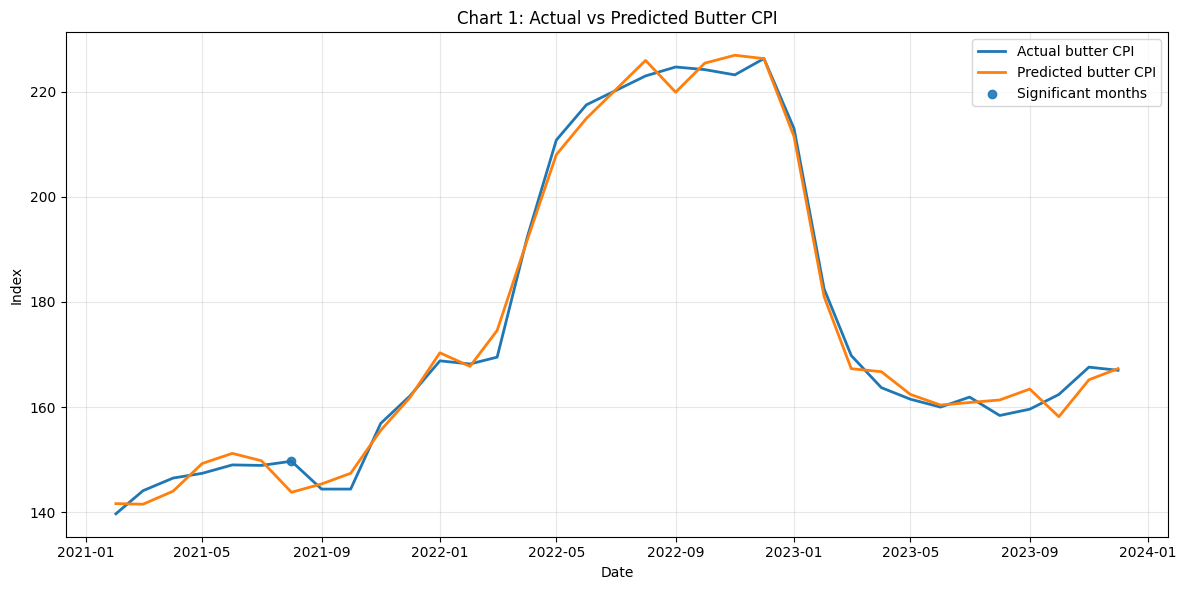

In [58]:
plot_line_chart(results_df)


## 12. Chart 2 – Bar chart


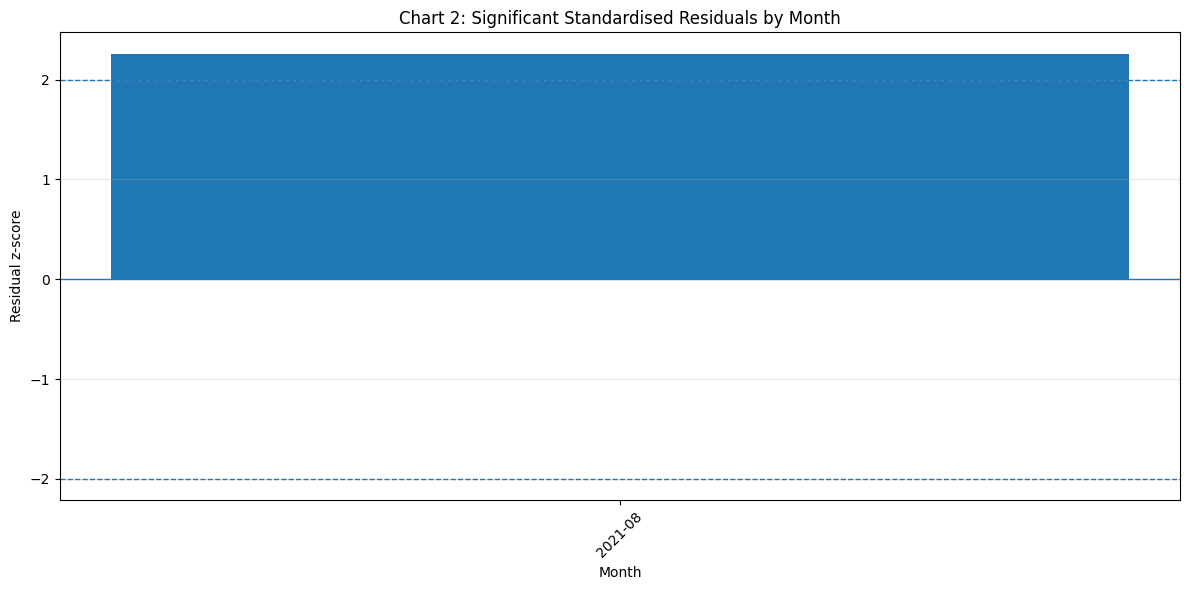

In [59]:
plot_bar_chart(significant_months_df)


## 13. Chart 3 – Boxplot


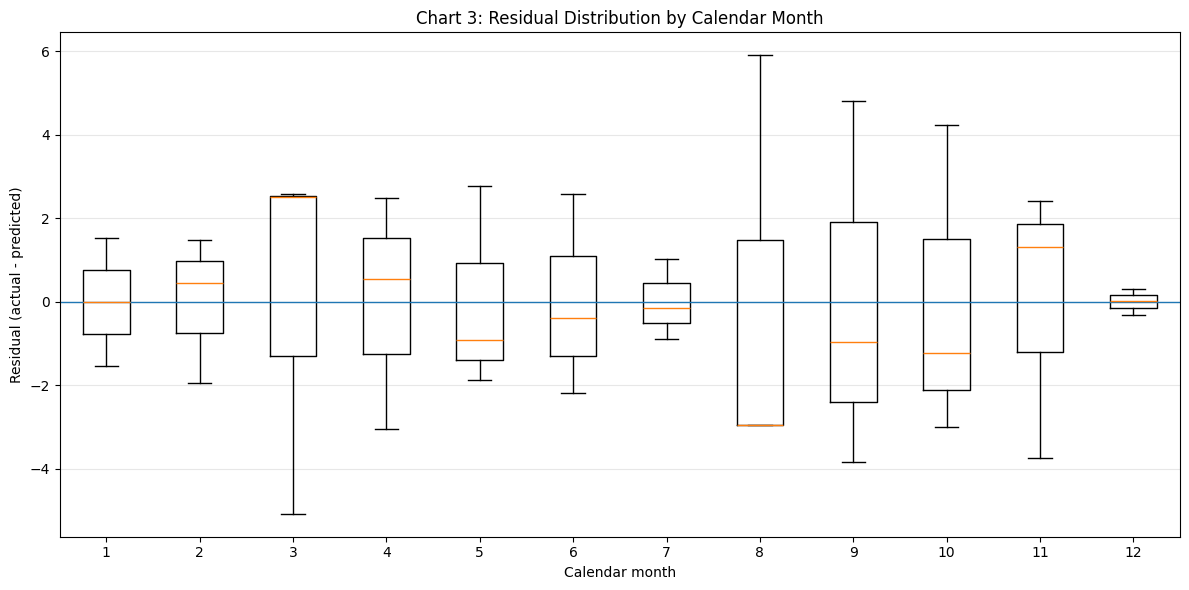

In [60]:
plot_boxplot(results_df)


## 14. Chart 4 – Scatter plot


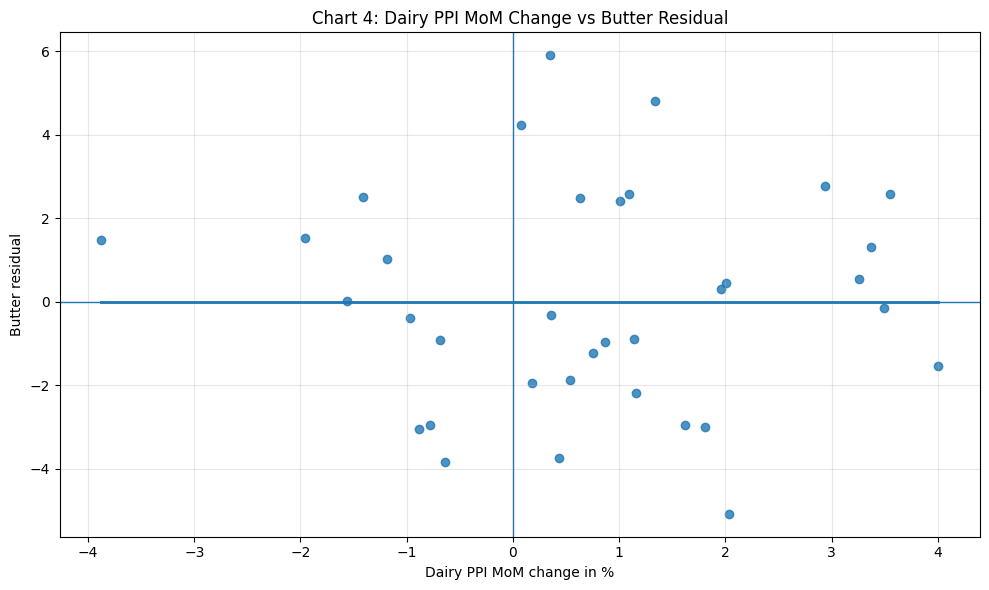

In [61]:
plot_scatter_chart(results_df)


## 15. Chart 5 – Heatmap


In [62]:
def plot_heatmap(results_df: pd.DataFrame) -> None:
    """Chart 5: Correlation heatmap of the key model variables."""
    columns = [
        "butter_cpi",
        "predicted_butter_cpi",
        "residual",
        "residual_zscore",
        "dairy_ppi",
        "dairy_cpi",
        "dairy_ppi_mom_pct",
        "dairy_cpi_mom_pct",
    ]

    # Nur Spalten verwenden, die wirklich existieren
    available_columns = [column for column in columns if column in results_df.columns]

    corr_matrix = results_df[available_columns].corr()

    plt.figure(figsize=(10, 7))
    image = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(image)

    plt.xticks(range(len(available_columns)), available_columns, rotation=45, ha="right")
    plt.yticks(range(len(available_columns)), available_columns)

    plt.title("Chart 5: Correlation Heatmap of Model Variables")
    plt.tight_layout()
    plt.show()

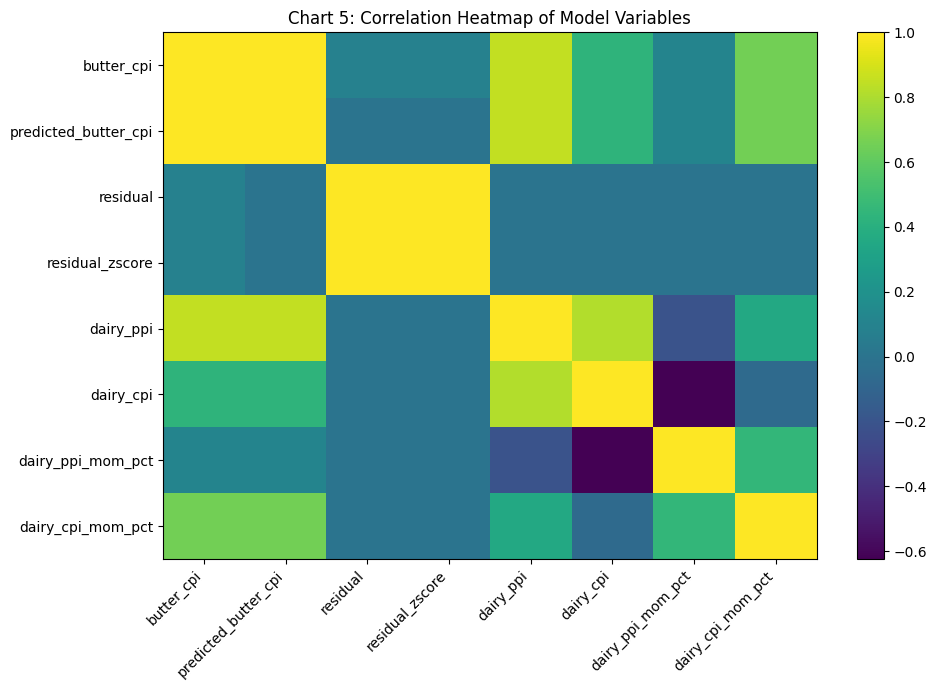

In [63]:
plot_heatmap(results_df)

## 16. Optional spoken conclusion for your presentation


In [64]:
print("Suggested presentation conclusion:")
print(
    "We used the uploaded API-export files for butter CPI, dairy PPI, and dairy CPI. "
    "After cleaning and merging the monthly time series, we built a simple explanatory model "
    "for butter prices that includes commodity trends, broader dairy inflation, seasonality, "
    "and a time trend. We then used standardised residuals to identify months between 2020 and 2024 "
    "in which retail butter prices were significantly higher or lower than expected."
)


Suggested presentation conclusion:
We used the uploaded API-export files for butter CPI, dairy PPI, and dairy CPI. After cleaning and merging the monthly time series, we built a simple explanatory model for butter prices that includes commodity trends, broader dairy inflation, seasonality, and a time trend. We then used standardised residuals to identify months between 2020 and 2024 in which retail butter prices were significantly higher or lower than expected.
